# Safe-to-Play: Athlete Injury Risk Prediction

**Group:** TXC-AS  
**Course:** Machine Learning 2026  
**Dataset:** High Accuracy Sport Injury Dataset (600 athletes)

---

> **Business Context:**  
> As the Performance Analytics department of a professional football club, our goal is to build a binary classification model: the *Safe-to-Play* classifier. It predicts injury risk based on physiological markers and training workload to support coaching staff in making data-driven decisions about player readiness.

# 1. Setup & Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap

# Global plot settings
mpl.rc('axes',  labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set_style('whitegrid')

RANDOM_STATE = 42  # fixed seed for reproducibility across all models and splits

# Feature-group colour palette (consistent throughout the notebook)
COLOR_BIO       = '#4C72B0'  # blue, biological markers
COLOR_LOAD      = '#DD8452'  # orange, training load
COLOR_RECOVERY  = '#55A868'  # green, recovery & lifestyle
COLOR_CONDITION = '#8172B2'  # purple, physical condition
COLOR_TARGET    = ['#2196F3', '#E53935']  # blue = no risk, red = at risk

print("Libraries loaded.")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded.


## 1.1 Data Loading

In [2]:
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


## 1.2 First Look

In [3]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

target_dist = pd.DataFrame({
    'Count': df['Injury_Risk'].value_counts(),
    '%': df['Injury_Risk'].value_counts(normalize=True).mul(100).round(1)
})
print(f"\nTarget distribution:\n{target_dist}")

Shape: (600, 16)

Data types:
Age                     int64
Gender                  int64
Height_cm             float64
Weight_kg             float64
BMI                   float64
Training_Frequency      int64
Training_Duration       int64
Warmup_Time             int64
Sleep_Hours           float64
Flexibility_Score     float64
Muscle_Asymmetry      float64
Recovery_Time           int64
Injury_History          int64
Stress_Level            int64
Training_Intensity    float64
Injury_Risk             int64
dtype: object

Missing values:
Age                   0
Gender                0
Height_cm             0
Weight_kg             0
BMI                   0
Training_Frequency    0
Training_Duration     0
Warmup_Time           0
Sleep_Hours           0
Flexibility_Score     0
Muscle_Asymmetry      0
Recovery_Time         0
Injury_History        0
Stress_Level          0
Training_Intensity    0
Injury_Risk           0
dtype: int64

Target distribution:
             Count     %
Injury_Risk    

**First look summary:**
- All 16 features are numeric (int64 / float64), so no encoding is needed for most variables
- No missing values across all 600 records. The dataset is clean and ready to use
- The target is imbalanced: **68.5% safe (0)** vs **31.5% at risk (1)**. We will account for this during modelling with stratified splits and class weighting

# 2. Exploratory Data Analysis

The EDA is structured to directly inform feature engineering decisions. We start with a full correlation overview, then dive into each feature group, and finish with cross-group interactions and a summary of what we take into Section 3.

## 2.1 Correlation with Target

Which features have the strongest relationship with injury risk?

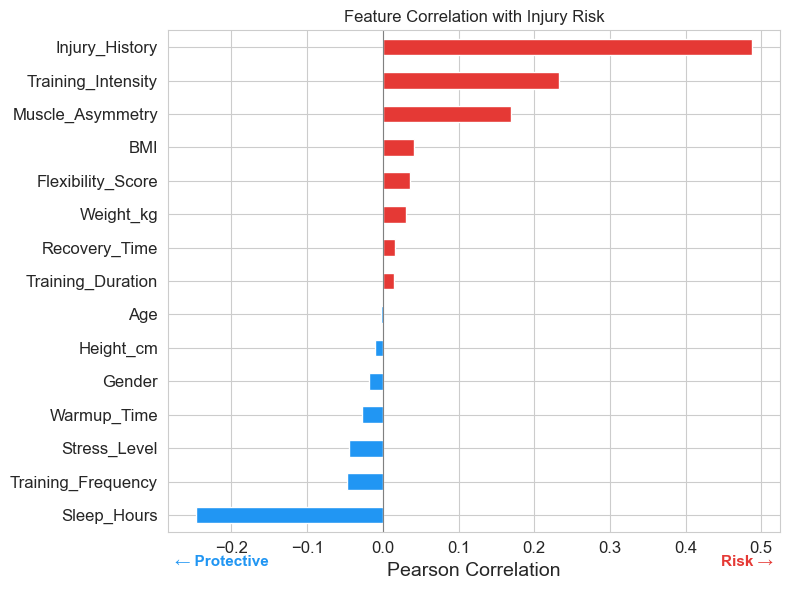

In [4]:
# Correlation of every feature with the target, sorted
corr_target = df.corr()['Injury_Risk'].drop('Injury_Risk').sort_values()

# Color bars by direction: positive = risk (red), negative = protective (blue)
bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in corr_target]

fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_title('Feature Correlation with Injury Risk')
ax.set_xlabel('Pearson Correlation')

# Label the two sides of the axis
ax.text(ax.get_xlim()[0] + 0.01, -1.2, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold', va='top')
ax.text(ax.get_xlim()[1] - 0.01, -1.2, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

**Key takeaways:**
- `Injury_History` is by far the strongest predictor. Prior injuries are the clearest signal of future risk.
- `Sleep_Hours` is the strongest protective factor. More sleep correlates with lower injury risk.
- Training load appears interestingly strong on both sides: `Training_Intensity` is the second strongest risk factor, while `Training_Frequency` is the second strongest protective factor, followed by `Stress_Level`. Unlike history or sleep, **training load is directly controllable by coaching staff.** `Training_Duration` is notably near zero.
- `Muscle_Asymmetry` is the third strongest risk factor. It is a physical/biomechanical signal, indicating that structural imbalances independently contribute to injury.
- `Recovery_Time` and `Warmup_Time` seem to be moderate predictors.
- `Age`, `BMI`, `Height_cm` and `Weight_kg` seem to be weak predictors.

Looking at these results, four natural groups emerge. Fixed physical characteristics like height, weight and age contribute little: professional athletes tend to be homogeneous in build, so these features do not differentiate well. How an athlete trains is a much stronger signal and, uniquely, something coaching staff can directly adjust. How well an athlete recovers day-to-day — sleep, recovery time, stress — reflects behavioural and psychological readiness. Finally, physical condition assessments like muscle asymmetry, flexibility and injury history capture the current medical and biomechanical state of the body, and contain some of the strongest predictors overall.

We will use this grouping to structure the rest of the EDA, examining each group in depth:

| Group | Features |
|---|---|
| Biological markers | Age, Gender, Height_cm, Weight_kg, BMI |
| Training load | Training_Frequency, Training_Duration, Training_Intensity, Warmup_Time |
| Recovery & lifestyle | Sleep_Hours, Recovery_Time, Stress_Level |
| Physical condition | Muscle_Asymmetry, Flexibility_Score, Injury_History |

## 2.2 Feature Groups

We examine each of the four groups for distribution shape, skew and separation between safe and at-risk athletes. This tells us which features need scaling, transformation or can be dropped.

### Biological Markers

In [5]:
# Readable injury class labels for all plots in this section
df['Injury_Class'] = df['Injury_Risk'].map({0: 'Safe', 1: 'At Risk'})
palette_class = {'Safe': COLOR_TARGET[0], 'At Risk': COLOR_TARGET[1]}

/var/folders/1d/khs53zqx6vbf7rqhnxmng9rr0000gn/T/ipykernel_64933/2504417914.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Female (0)', 'Male (1)'])


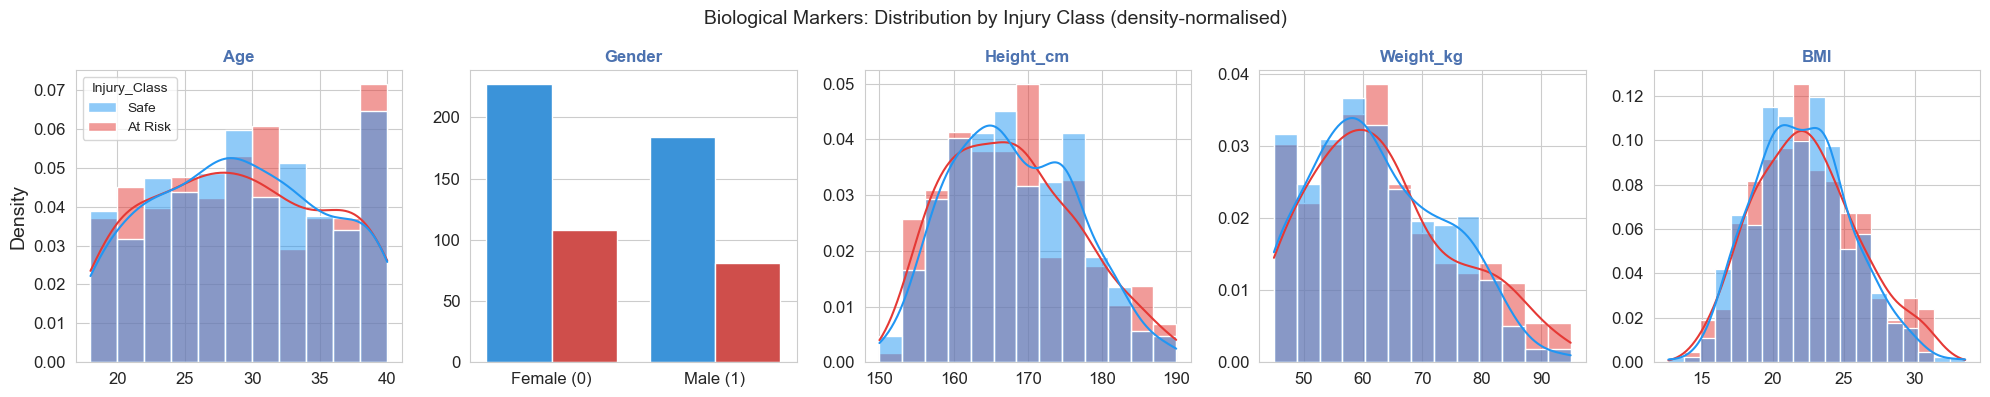

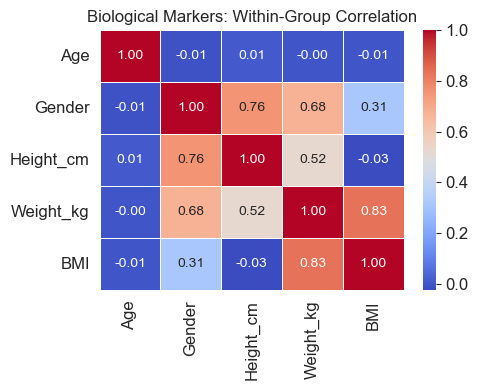

In [6]:
bio_features = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(bio_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 2:
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        axes[i].set_xticklabels(['Female (0)', 'Male (1)'])
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        # stat='density' normalises each class so shapes are comparable despite class imbalance
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_BIO, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Biological Markers: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[bio_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Biological Markers: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- Age, Height and Weight distributions overlap almost entirely between classes. Visually, there is little separation.
- BMI shows a slight rightward shift for at-risk athletes, but the overlap is still large.
- Gender appears relatively balanced across classes, though hard to judge from counts alone given class imbalance.
- We run two statistical tests to confirm these visual impressions before deciding what to keep.

In [7]:
from scipy.stats import chi2_contingency, mannwhitneyu

safe     = df[df['Injury_Risk'] == 0]
at_risk  = df[df['Injury_Risk'] == 1]

# Chi-squared: Gender vs Injury Risk (categorical)
contingency_table = pd.crosstab(df['Gender'], df['Injury_Risk'])
chi2, p_gender, dof, _ = chi2_contingency(contingency_table)

# Mann-Whitney U: Age vs Injury Risk (continuous, non-parametric)
stat_age, p_age = mannwhitneyu(safe['Age'], at_risk['Age'], alternative='two-sided')

print("Statistical Tests: Biological Markers")
print()
print(f"Gender (Chi-squared):  chi2={chi2:.4f},  p={p_gender:.4f}  ->  {'significant' if p_gender < 0.05 else 'not significant'}")
print(f"Age    (Mann-Whitney): U={stat_age:.0f},     p={p_age:.4f}  ->  {'significant' if p_age    < 0.05 else 'not significant'}")

Statistical Tests: Biological Markers

Gender (Chi-squared):  chi2=0.1222,  p=0.7267  ->  not significant
Age    (Mann-Whitney): U=39026,     p=0.9248  ->  not significant


**Feature classification: Biological Markers**

| Feature | p-value | Classification |
|---|---|---|
| `BMI` | n/a | Test to drop in model phase |
| `Gender` | 0.05+ | Descriptive variable (demographic control) |
| `Age` | 0.05+ | Excluded (near-zero correlation, not significant) |
| `Height_cm` | n/a | Excluded (redundant with BMI) |
| `Weight_kg` | n/a | Excluded (redundant with BMI) |

See 2.4 for the full feature classification across all groups.

### Training Load

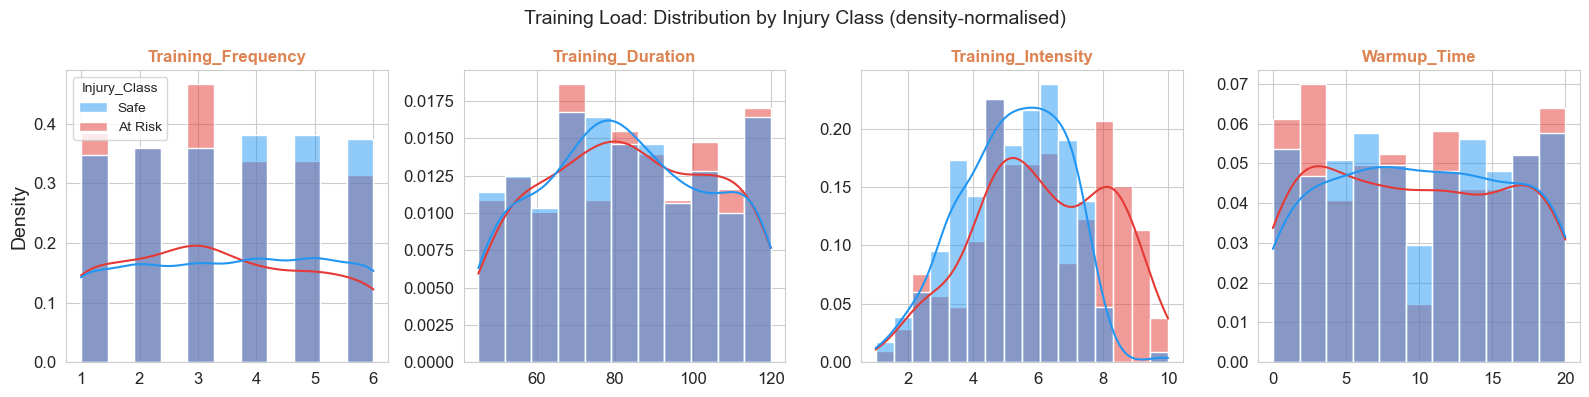

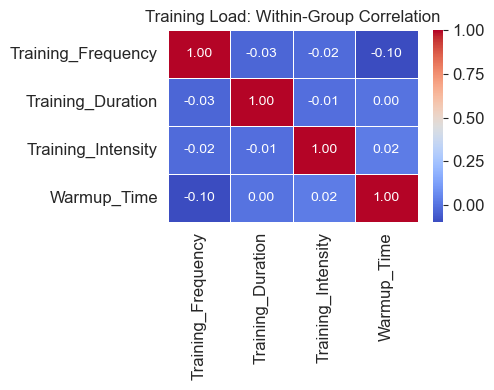

In [8]:
load_features = ['Training_Frequency', 'Training_Duration', 'Training_Intensity', 'Warmup_Time']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(load_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_LOAD, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Training Load: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[load_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Training Load: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Training_Intensity` shows the clearest separation between classes. At-risk athletes tend to train at higher intensities.
- `Training_Frequency` shifts slightly toward lower values for at-risk athletes, suggesting less frequent but harder training is a risk pattern.
- `Training_Duration` and `Warmup_Time` show heavy overlap. Their individual signal looks weak visually.
- No multicollinearity within this group (heatmap near zero). We run Mann-Whitney U tests to confirm which features are statistically significant.

In [9]:
print("Statistical Tests: Training Load (Mann-Whitney U)\n")
for feat in load_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Training Load (Mann-Whitney U)

  Training_Frequency        U=41121,  p=0.2408  ->  not significant
  Training_Duration         U=38128,  p=0.7185  ->  not significant
  Training_Intensity        U=28776,  p=0.0000  ->  significant
  Warmup_Time               U=40210,  p=0.4870  ->  not significant


**Feature classification: Training Load**

| Feature | p-value | Classification |
|---|---|---|
| `Training_Intensity` | 0.0000 | Clear good feature |
| `Training_Frequency` | 0.2408 | Test to drop in model phase |
| `Training_Duration` | 0.7185 | Test to drop in model phase |
| `Warmup_Time` | 0.4870 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Recovery & Lifestyle

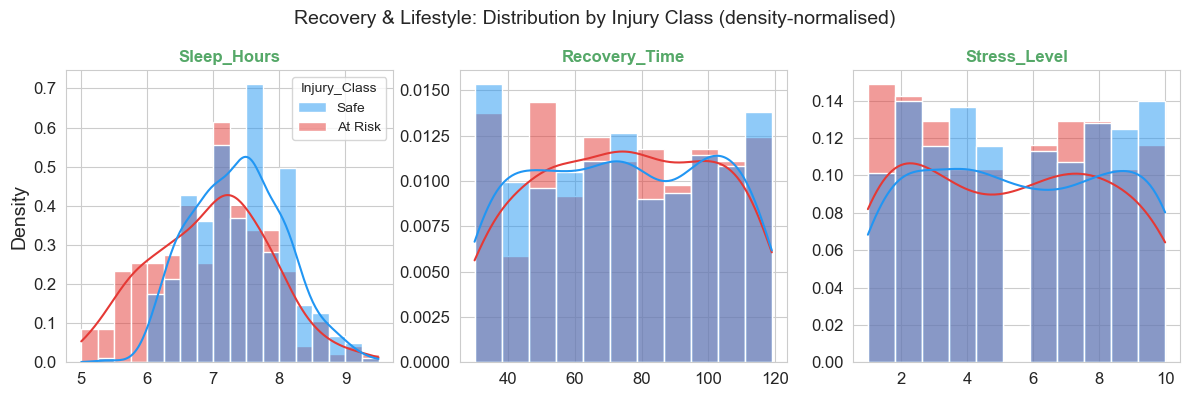

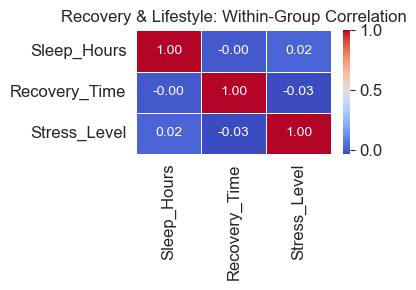

In [10]:
recovery_features = ['Sleep_Hours', 'Recovery_Time', 'Stress_Level']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(recovery_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_RECOVERY, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Recovery & Lifestyle: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[recovery_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Recovery & Lifestyle: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Sleep_Hours` shows a clear leftward shift for at-risk athletes. Less sleep is visually the strongest signal in this group.
- `Stress_Level` shows a slight separation but in the protective direction, which is counterintuitive.
- `Recovery_Time` shows heavy overlap between classes. Its signal looks weak visually.
- We run Mann-Whitney U tests to confirm significance before deciding what to keep.

In [11]:
print("Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)\n")
for feat in recovery_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)

  Sleep_Hours               U=49461,  p=0.0000  ->  significant
  Recovery_Time             U=38060,  p=0.6929  ->  not significant
  Stress_Level              U=41032,  p=0.2640  ->  not significant


**Feature classification: Recovery & Lifestyle**

| Feature | p-value | Classification |
|---|---|---|
| `Sleep_Hours` | 0.0000 | Clear good feature |
| `Stress_Level` | 0.2640 | Test to drop in model phase |
| `Recovery_Time` | 0.6929 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Physical Condition

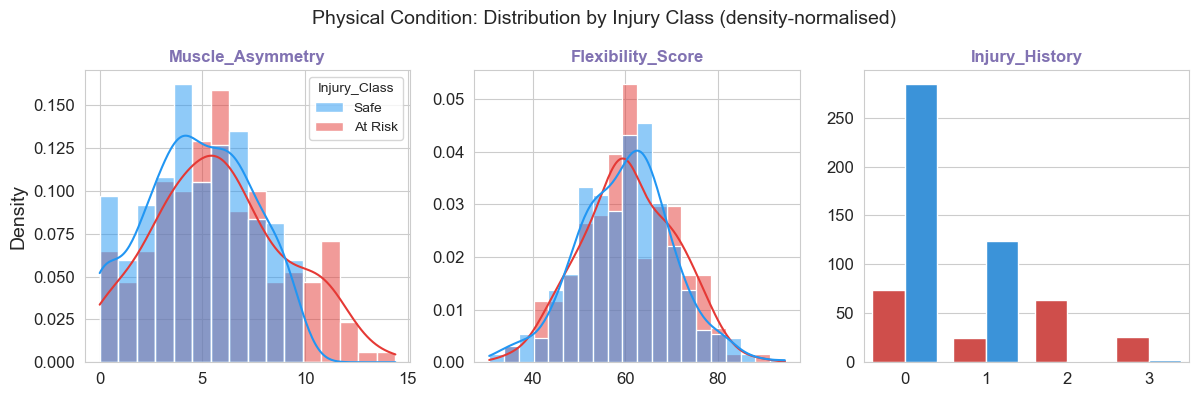

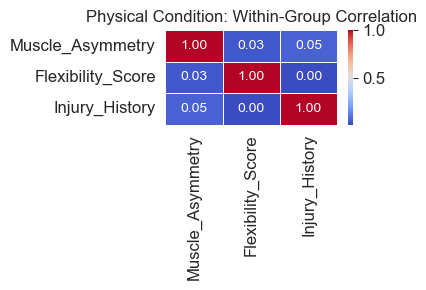

In [12]:
condition_features = ['Muscle_Asymmetry', 'Flexibility_Score', 'Injury_History']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(condition_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 5:  # treat as categorical if few unique values
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_CONDITION, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Physical Condition: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[condition_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Physical Condition: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Injury_History` shows the starkest separation of any feature in the entire dataset. Athletes with prior injuries are heavily concentrated in the at-risk class.
- `Muscle_Asymmetry` shows a rightward shift for at-risk athletes. Structural imbalances appear to be a meaningful signal.
- `Flexibility_Score` shows considerable overlap. Its value as a standalone predictor looks limited visually.
- We run Mann-Whitney U tests to confirm which features are statistically significant.

In [13]:
print("Statistical Tests: Physical Condition (Mann-Whitney U)\n")
for feat in condition_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Physical Condition (Mann-Whitney U)

  Muscle_Asymmetry          U=32240,  p=0.0008  ->  significant
  Flexibility_Score         U=37330,  p=0.4441  ->  not significant
  Injury_History            U=21717,  p=0.0000  ->  significant


**Feature classification: Physical Condition**

| Feature | p-value | Classification |
|---|---|---|
| `Injury_History` | 0.0000 | Clear good feature |
| `Muscle_Asymmetry` | 0.0008 | Clear good feature |
| `Flexibility_Score` | 0.4441 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

## 2.3 Cross-Group Interactions

A full correlation matrix across all features. This reveals multicollinearity between groups and hints at interaction features worth engineering (e.g. high training intensity combined with low sleep).

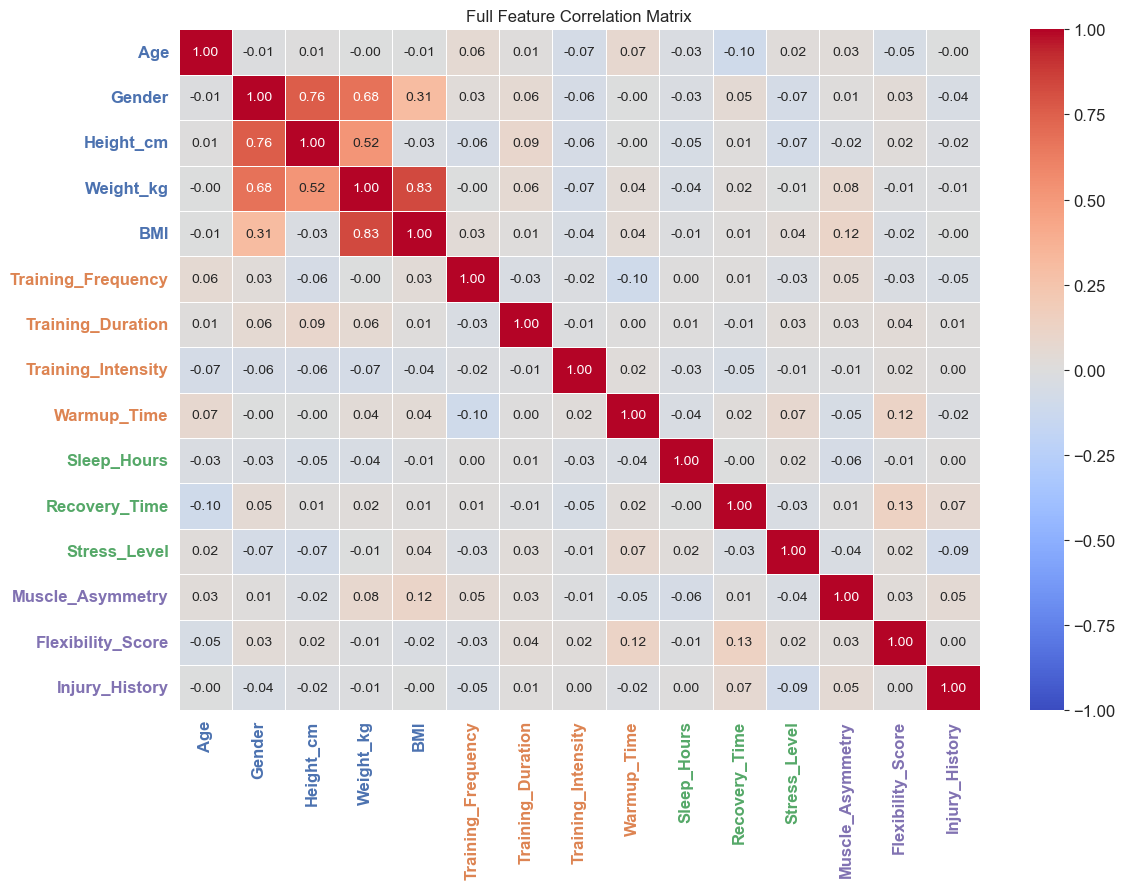

In [14]:
# Full correlation matrix, ordered by feature group for readability
all_features = bio_features + load_features + recovery_features + condition_features
corr_full = df[all_features].corr()

# Map each feature to its group color
feature_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix')

# Color axis labels by feature group
for tick in ax.get_xticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Cross-group observations:**

**Multicollinearity within biological markers:** `Height_cm`, `Weight_kg` and `BMI` are highly correlated (Weight-BMI: r=0.83, Gender-Height: r=0.76, Gender-Weight: r=0.68). `Gender` is essentially a size proxy in this dataset: males tend to be taller and heavier, which explains why gender itself adds no independent injury signal. We retain only `BMI` and drop the rest.

**The four strongest predictors are independent from each other:** `Injury_History`, `Training_Intensity`, `Sleep_Hours` and `Muscle_Asymmetry` show near-zero correlations with one another. This is important: they capture genuinely different aspects of athlete condition with no redundancy. For a Logistic Regression model, low multicollinearity among key features means coefficients will be stable and interpretable.

**Training intensity is independent from volume:** `Training_Intensity` has near-zero correlation with both `Training_Duration` and `Training_Frequency`. An athlete can train hard for short sessions or easy for long ones. Intensity is a qualitatively different signal from how much or how often an athlete trains.

**Stress and sleep are unrelated:** `Stress_Level` and `Sleep_Hours` show near-zero correlation (-0.09). One might expect high stress to reduce sleep in professional athletes, but this dataset suggests the two are driven by different factors. It also confirms they would not be redundant if both were kept.

**No cross-group dependencies of concern:** recovery features (Sleep, Stress, Recovery_Time) are uncorrelated with physical condition features (Muscle_Asymmetry, Flexibility, Injury_History). Each group captures a distinct dimension of athlete readiness, which justifies treating them as separate input signals rather than collapsing them.

## 2.4 Class Separability: t-SNE Visualisation

Before building any model, it is worth asking: do the features together actually separate safe from at-risk athletes? t-SNE compresses all 12 features into 2 dimensions while trying to keep similar athletes close together. The result is a scatter plot where each dot is one athlete. If the two classes form distinct clusters, a classifier will have a good chance of learning the boundary.

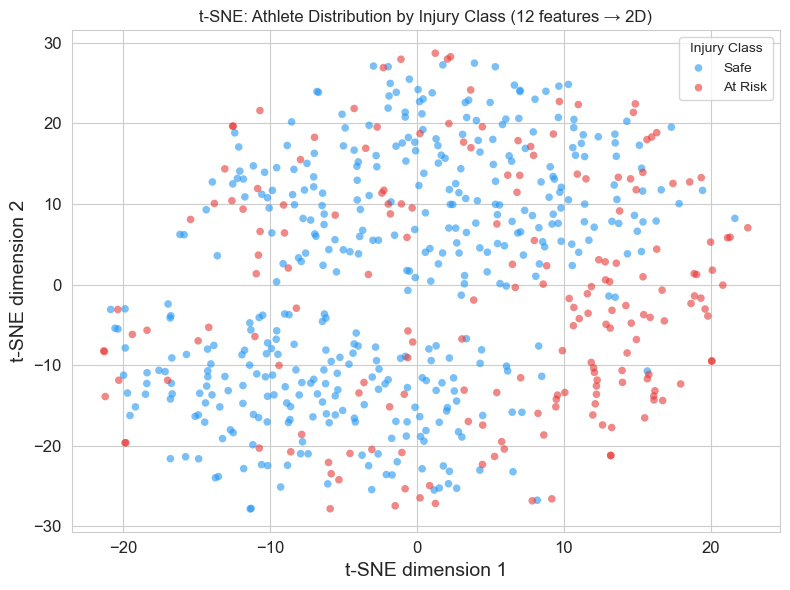

In [23]:
from sklearn.manifold import TSNE

# Use the same 12 features that enter the models (excluding Age, Height_cm, Weight_kg)
tsne_features = [c for c in df.columns if c not in
                 ['Age', 'Height_cm', 'Weight_kg', 'Injury_Risk', 'Injury_Class']]

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(df[tsne_features]))

tsne_df = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1],
                        'Injury_Class': df['Injury_Class']})

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [('Safe', COLOR_TARGET[0]), ('At Risk', COLOR_TARGET[1])]:
    mask = tsne_df['Injury_Class'] == label
    ax.scatter(tsne_df.loc[mask, 'x'], tsne_df.loc[mask, 'y'],
               c=color, label=label, alpha=0.6, s=30, edgecolors='none')

ax.set_title('t-SNE: Athlete Distribution by Injury Class (12 features → 2D)')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.legend(title='Injury Class')
plt.tight_layout()
plt.show()

The t-SNE plot shows meaningful separation between classes: at-risk athletes (red) tend to cluster in specific regions of the 2D space, distinct from safe athletes (blue). The separation is not perfect — some overlap remains — which is consistent with real-world injury data where multiple borderline cases exist. Importantly, the partial separation confirms that the 12 features carry enough signal for a classifier to learn the boundary, setting realistic expectations for model performance in Section 4.

## 2.5 EDA Summary: Feature Classification

We organised the 15 features into four groups based on what they measure: biological markers, training load, recovery & lifestyle, and physical condition. Across all groups, the EDA reveals a clear pattern. Physical condition is the strongest signal, with `Injury_History` and `Muscle_Asymmetry` standing out. Training load is uniquely two-sided: high intensity increases risk, while frequency is protective. Sleep is the strongest lifestyle factor. Biological markers contribute little, likely because athletes in a professional club are physically homogeneous.

All 15 features are classified below based on two criteria: statistical significance (group-level tests) and correlation with the target (2.1).

| Feature | r with target | Significant? | Classification |
|---|---|---|---|
| `Injury_History` | 0.49 | Yes | **Clear good feature** |
| `Training_Intensity` | 0.23 | Yes | **Clear good feature** |
| `Sleep_Hours` | -0.25 | Yes | **Clear good feature** |
| `Muscle_Asymmetry` | 0.17 | Yes | **Clear good feature** |
| `Training_Frequency` | -0.13 | No | Test to drop in model phase |
| `Stress_Level` | -0.12 | No | Test to drop in model phase |
| `BMI` | 0.07 | No | Test to drop in model phase |
| `Flexibility_Score` | 0.07 | No | Test to drop in model phase |
| `Warmup_Time` | -0.08 | No | Test to drop in model phase |
| `Training_Duration` | 0.05 | No | Test to drop in model phase |
| `Recovery_Time` | 0.04 | No | Test to drop in model phase |
| `Gender` | -0.05 | No | Descriptive variable (kept as demographic control) |
| `Age` | 0.00 | No | Excluded |
| `Height_cm` | 0.00 | No | Excluded (redundant with BMI) |
| `Weight_kg` | 0.00 | No | Excluded (redundant with BMI) |

"Test to drop in model phase" features will be included in Section 3 and evaluated during model comparison. Features that do not contribute to performance will be removed at that stage.

**Steps in Section 3:**
- Apply `StandardScaler` to all continuous features (different scales and units)
- Split: 70% train / 30% test, stratified on target, `random_state=42`. Model selection via 5-fold `StratifiedKFold` cross-validation on the train set. Test set held out for final evaluation only.

# 3. Feature Engineering

Based on the EDA findings, we now prepare the data for modelling. This section drops the excluded features, scales the remaining ones, and creates the three splits used throughout Section 4.

## 3.1 Drop Excluded Features

We remove `Age`, `Height_cm` and `Weight_kg` as established in the EDA. `Injury_Class` (the readable label column created for plots) is also removed as it is not a model input.

In [15]:
cols_to_drop = ['Age', 'Height_cm', 'Weight_kg', 'Injury_Class']
df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=['Injury_Risk'])
y = df_model['Injury_Risk']

print(f"Features going into modelling ({X.shape[1]}): {list(X.columns)}")
print(f"Target: Injury_Risk, shape: {y.shape}")

Features going into modelling (12): ['Gender', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity']
Target: Injury_Risk, shape: (600,)


## 3.2 Train / Test Split

We split into 70% train and 30% test. The train set is used with 5-fold cross-validation for model selection. The test set is held out completely and only used for final evaluation.

In [16]:
from sklearn.model_selection import StratifiedKFold

# 70% train, 30% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# StratifiedKFold for cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Class balance per split:")
for name, y_split in [("Train", y_train), ("Test", y_test)]:
    pct = y_split.value_counts(normalize=True).mul(100).round(1)
    print(f"  {name:<8}: Safe {pct[0]}%  |  At Risk {pct[1]}%")
print()
print(f"Cross-validation: {cv.n_splits}-fold StratifiedKFold on train set")

Train : 420 samples (70%)
Test  : 180 samples (30%)

Class balance per split:
  Train   : Safe 68.6%  |  At Risk 31.4%
  Test    : Safe 68.3%  |  At Risk 31.7%

Cross-validation: 5-fold StratifiedKFold on train set


## 3.3 Scaling

`StandardScaler` is fitted on the training set only and applied to the test set. This prevents data leakage: the test set must not influence the scaling parameters.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# Wrap back into DataFrames to keep feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean().round(2).values}")
print(f"Train std  (should be ~1): {X_train_scaled.std().round(2).values}")

Scaling complete.
Train mean (should be ~0): [-0. -0.  0. -0. -0.  0.  0. -0.  0. -0. -0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Section 3 summary:**
- 3 features excluded: `Age`, `Height_cm`, `Weight_kg`
- 12 features entering the models: 4 clear good features + 7 to test for dropping + `Gender` as descriptive control
- Split: 420 train (70%) / 180 test (30%), class balance preserved in both
- Model selection via 5-fold StratifiedKFold cross-validation on the train set
- Scaler fitted on train only to prevent data leakage

# 4. Model Training

We train three models of increasing complexity: a **Logistic Regression** as the linear baseline, a **Random Forest** as a non-linear ensemble, and **XGBoost** as a gradient boosting model.

For each model we follow the same protocol:
1. Train on the 420-sample training set
2. Evaluate via 5-fold stratified cross-validation on the training set
3. Predict on the 180-sample held-out test set
4. Report: accuracy, precision, recall, F1, ROC-AUC

All metrics are reported on the test set so comparisons are fair. Cross-validation scores on the training set confirm the model generalises rather than overfits.

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV

# Reusable evaluation helper: returns all 5 metrics for any fitted classifier
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test,    y_pred), 4),
        'F1':        round(f1_score(y_test,        y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test,  y_prob), 4),
    }

## 4.1 Logistic Regression with RFE

**Logistic Regression** is the natural linear baseline for binary classification. It models the log-odds of injury risk as a linear combination of the input features and outputs a probability between 0 and 1. It is interpretable, fast to train, and gives us a clear benchmark to assess whether more complex models add value.

**Why RFE?** We enter Section 4 with 12 features, several of which were flagged in the EDA as weak predictors. Recursive Feature Elimination (RFE) ranks all features by their importance to the model, removing the least useful ones step by step. By setting `n_features_to_select=1` we obtain a full ranking from strongest (rank 1) to weakest (rank 12). This lets us inspect the ranking and choose the cutoff based on where the signal drops off, rather than guessing upfront.

We use `class_weight='balanced'` to account for the 68.5/31.5 class imbalance.

RFE Feature Ranking (rank 1 = most important):

           Feature  Rank
    Injury_History     1
Training_Intensity     2
       Sleep_Hours     3
  Muscle_Asymmetry     4
Training_Frequency     5
 Flexibility_Score     6
     Recovery_Time     7
 Training_Duration     8
               BMI     9
       Warmup_Time    10
      Stress_Level    11
            Gender    12


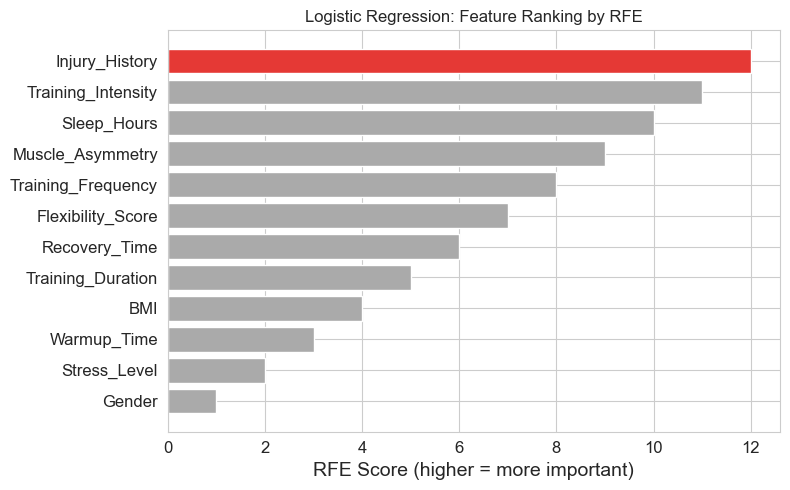

In [19]:
from sklearn.feature_selection import RFE

# RFE with n_features_to_select=1 gives a unique rank to every feature
lr_rfe = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
rfe = RFE(estimator=lr_rfe, n_features_to_select=1)
rfe.fit(X_train_scaled, y_train)

# Build a summary table: rank 1 = most important, 12 = least important
rfe_ranking = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Rank':    rfe.ranking_
}).sort_values('Rank')

print("RFE Feature Ranking (rank 1 = most important):\n")
print(rfe_ranking.to_string(index=False))

# Visualise the ranking
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLOR_TARGET[1] if r == 1 else '#AAAAAA' for r in rfe_ranking['Rank']]
ax.barh(rfe_ranking['Feature'], rfe_ranking['Rank'].max() - rfe_ranking['Rank'] + 1,
        color=colors)
ax.set_xlabel('RFE Score (higher = more important)')
ax.set_title('Logistic Regression: Feature Ranking by RFE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The ranking reveals a clear structure: a strong top group (`Injury_History`, `Training_Intensity`, `Sleep_Hours`, `Muscle_Asymmetry`) followed by a middle group with moderate signal, and a bottom cluster of four features (`BMI`, `Warmup_Time`, `Stress_Level`, `Gender`) that contribute least. We set `N_FEATURES = 8`, retaining the top two groups and dropping the bottom four. This aligns with our EDA conclusions and avoids introducing noise from features with no meaningful predictive signal.

In [20]:
N_FEATURES = 8  # drop the 4 weakest by RFE: Gender, Stress_Level, Warmup_Time, BMI

# Select top N features by RFE rank
selected_features = rfe_ranking[rfe_ranking['Rank'] <= N_FEATURES]['Feature'].tolist()
print(f"Selected {N_FEATURES} features: {selected_features}")

X_train_lr = X_train_scaled[selected_features]
X_test_lr  = X_test_scaled[selected_features]

# Train final Logistic Regression on selected features
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_lr, y_train)

# 5-fold cross-validation on train set (confirms the model generalises)
cv_scores = cross_val_score(log_reg, X_train_lr, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC (5-fold): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"Per fold:            {cv_scores.round(4)}")

Selected 8 features: ['Injury_History', 'Training_Intensity', 'Sleep_Hours', 'Muscle_Asymmetry', 'Training_Frequency', 'Flexibility_Score', 'Recovery_Time', 'Training_Duration']

CV ROC-AUC (5-fold): 0.8857  ±  0.0374
Per fold:            [0.9231 0.9058 0.8992 0.8148 0.8856]


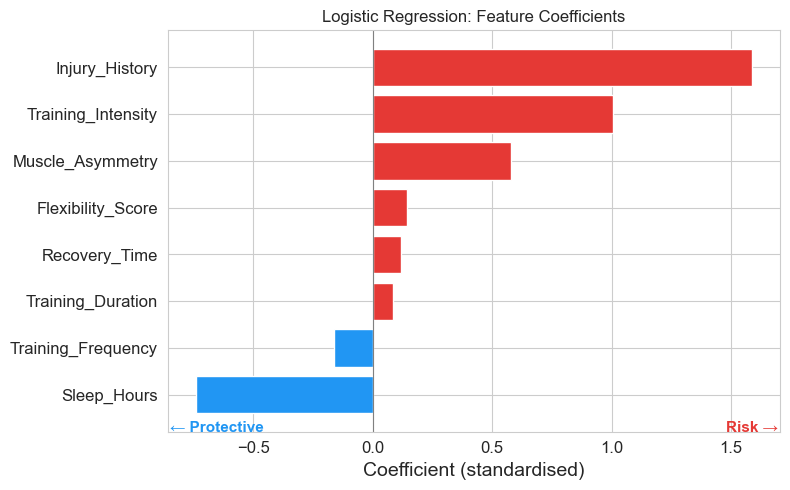

In [21]:
# Model coefficients: absolute importance and direction for each feature
coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient')

bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Logistic Regression: Feature Coefficients')
ax.text(ax.get_xlim()[0] + 0.01, -0.8, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold')
ax.text(ax.get_xlim()[1] - 0.01, -0.8, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

Test Set Performance: Logistic Regression

  Accuracy    : 0.8000
  Precision   : 0.6567
  Recall      : 0.7719
  F1          : 0.7097
  ROC-AUC     : 0.8258


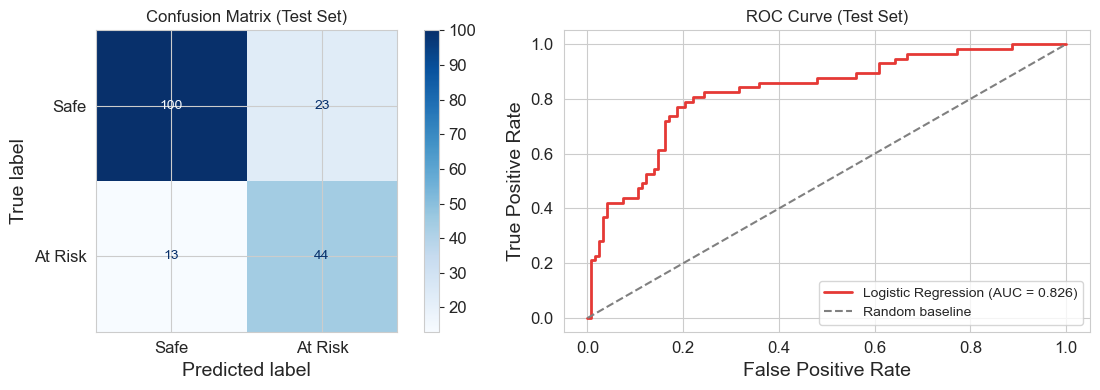

In [22]:
# Test set evaluation
lr_metrics = evaluate_model(log_reg, X_test_lr, y_test)
print("Test Set Performance: Logistic Regression\n")
for metric, value in lr_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_lr, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Test Set)')

# ROC curve
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color=COLOR_TARGET[1], lw=2,
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Logistic Regression results:**

The RFE ranking and the coefficient plot tell two complementary stories. RFE shows the relative order of importance; the coefficients show the actual magnitude and direction each feature contributes in the fitted model, confirming that `Injury_History` and `Training_Intensity` dominate, while `Sleep_Hours` acts as the strongest protective signal.

**Test set performance (180 athletes):**

| Metric | Value |
|---|---|
| Accuracy | 0.800 |
| Precision | 0.657 |
| Recall | 0.772 |
| F1 | 0.710 |
| ROC-AUC | **0.826** |

**Confusion matrix:** Of the 57 at-risk athletes in the test set, the model correctly flags 44 (recall 77.2%) and misses 13 (false negatives). Of the 123 safe athletes, 100 are correctly cleared and 23 are unnecessarily flagged (false positives). The 13 missed at-risk athletes are the most costly errors from a business perspective.

**ROC curve:** An AUC of 0.826 means the model correctly ranks a randomly selected at-risk athlete above a randomly selected safe athlete 82.6% of the time. The curve rises steeply at low false positive rates, which is exactly what we want: the model can identify a large fraction of at-risk athletes while keeping the false alarm rate manageable. This is a strong linear baseline.

Logistic Regression captures main effects but cannot model non-linear interactions (e.g. the combined effect of high training intensity and low sleep). Sections 4.2 and 4.3 address this with tree-based models and we expect the AUC to improve further.